In [33]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"]="false"
# Set the JAX device platform to CPU
os.environ['JAX_PLATFORM_NAME'] = 'cpu'
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
import seaborn as sns
from jax import random
from nioc.envs import Pouring_base

import warnings
warnings.filterwarnings("ignore")

import pysindy as ps
from sklearn.metrics import root_mean_squared_error
from scipy.interpolate import interp1d



In [34]:
import os, zipfile, requests
from tqdm.notebook import tqdm

DATA_URL = "https://zenodo.org/records/22163061/files/data.zip?download=1"

if not os.path.exists("data"):
    print("Downloading data from Zenodo...")
    resp = requests.get(DATA_URL, stream=True)
    total = int(resp.headers.get("content-length", 0))

    with open("data.zip", "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
        for chunk in resp.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))

    print("Extracting...")
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall(".")
    os.remove("data.zip")
    print("Done.")
else:
    print("data/ already exists, skipping download.")

data/ already exists, skipping download.


In [35]:
from utils import *
from controller_helpers import *

In [36]:
data_master_trajectories = load_saved_trajectories('data/pouring_trajectories_data.h5')

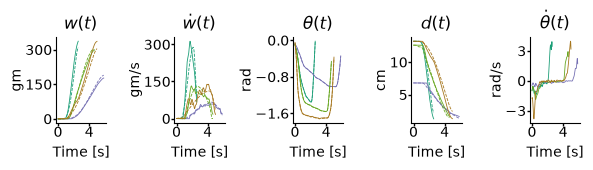

In [37]:
# Plot SINDYc forward simulation

def plot_sindy_traces(sindy_plot_data, figsize=(6, 1.8)):
    cols = [
        (0, r'${w}(t)$', 'gm'),
        (1, r'$\dot{w}(t)$', 'gm/s'),
        (2, r'${\theta}(t)$', 'rad'),
        ('headroom', r'${d}(t)$', 'cm'),
        ('u', r'$\dot{\theta}(t)$', 'rad/s'),
    ]
    cmap = plt.get_cmap('Dark2')
    n = len(sindy_plot_data)
    lw = 0.6
    fig, axs = plt.subplots(1, 5, figsize=figsize)

    for i, d in enumerate(sindy_plot_data):
        c = cmap(i / n)
        t = d['t']
        w, pred, u = d['w'], d['pred'], d['u']

        for j, (col, title, ylabel) in enumerate(cols):
            ax = axs[j]
            if col == 'headroom':
                y_data = d['headroom_data']
                y_sim = d['headroom_sim'][:-1]
            elif col == 'u':
                ax.plot(t, u[:], c=c, label=d['label'], linewidth=lw)
                continue
            else:
                y_data = w[:, col]
                y_sim = pred[:-1, col]

            ax.plot(t, y_data, c=c, linewidth=lw)
            ax.plot(t, y_sim, '--', c=c, linewidth=lw)

    for j, (_, title, ylabel) in enumerate(cols):
        ax = axs[j]
        ax.set_title(title)
        ax.set_ylabel(ylabel, labelpad=1.)
        ax.set_xlabel("Time [s]")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
        ax.tick_params(axis='both', pad=0.5)
        simpleaxis(ax, constrained=False, direction='out', tickLen=2)

    plt.show()
    plt.close('all')

# Plot 4 example trajectories
trials_to_extract = [
    ('Beaker', 'MAGEMU', 'MugBeaker', 'fast'),
    ('Beaker', 'FRTHIL', 'ConicalBeaker', None),
    ('Vase', 'SHGIBA', 'GobletVase', None),
    ('Bottle', 'MAGEMU', 'MugBottle', 'fast'),
]

sindy_plot_data = []

for container, participant, combo, task in trials_to_extract:
    combo_key = f'{combo}_{task}' if task else combo
    
    data_e = data_master_trajectories[participant][combo_key]
    trajs = data_e['trajectories_control']
    
    # take 1st trial of test set (last 20% is test set)
    split = int(len(trajs) * 0.8)
    trial = trajs[split]
    
    w = trial[:, [0, 1, 2]]
    u = trial[:, [4]]
    t = np.linspace(0, len(trial) * dt, len(trial), endpoint=False)
    
    cup_name = get_vessel_name(combo_key)
    dynamics_func = sindy_dynamics_functions_dict[container]
    pred = simulate_dynamics(dynamics_func, w[0], u)
    headroom_data = max_heights[cup_name] - calculate_height_arr(cup_name, w[:, 0])
    headroom_sim = max_heights[cup_name] - calculate_height_arr(cup_name, pred[:, 0])
    
    sindy_plot_data.append({
        'label': f'{participant}_{combo_key}',
        't': t, 'w': w, 'pred': pred, 'u': u,
        'headroom_data': headroom_data, 'headroom_sim': headroom_sim,
    })


plot_sindy_traces(sindy_plot_data)

In [38]:
#ilqg

key = random.PRNGKey(1)

def build_interpolators(trajs, extrapolate=True):
    """Return a list of interp1d objects, one per trajectory.
    trajs: list of arrays shape (ti, D)
    """
    interps = []
    for traj in trajs:
        t_orig = np.linspace(0, 1, traj.shape[0])
        interp = interp1d(t_orig, traj, axis=0, kind='linear',
                          fill_value="extrapolate" if extrapolate else None,
                          bounds_error=False)
        interps.append(interp)
    return interps

def get_uinit_from_interps(interps, T):
    t_target = np.linspace(0, 1, T)
    normed = np.stack([interp(t_target) for interp in interps], axis=0)
    mean = normed.mean(axis=0)
    return mean.reshape((T,1))

def resample_from_interps(interps, T):
    t_target = np.linspace(0, 1, T)
    return np.stack([interp(t_target) for interp in interps], axis=0)  # (N,T,D)

def get_avg_traj(traj):
    mean = traj.mean(axis=0)
    std = traj.std(axis=0)
    return mean, std

u_interp_dict = {}
for container in ['Bottle', 'Beaker', 'Vase']:
    container_u_trials = []
    for p, data_p in data_master_trajectories.items():
        for e, data_e in data_p.items():
            if container not in e:
                continue
            for t in data_e['trajectories_control']:
                container_u_trials.append(t[:, -1]) #only take the u

    interp_funcs = build_interpolators(container_u_trials)
    u_interp_dict[container] = interp_funcs


def plot_ilqq_trajectories(xs_ilqg, us_ilqg, data_human_traj):
    fig = plt.figure(figsize=(6,1.5))
    mean_s = xs_ilqg.mean(axis=0)    
    mean_d, std_d = get_avg_traj(data_human_traj)  

    model_color = "#FF6E00"
    data_color = "#000000"
        
    subplots=[]
    for i in range(5):
        subplots.append(fig.add_subplot(1,5,i+1))
    name =[r'${w}(t)$', r'$\dot{w}(t)$',r'${\theta}(t)$',r'${d}(t)$',r'$\dot{\theta}(t)$']  
    xlabel =['gm', 'gm/s','rad','cm','rad/s']  
    ylimits = [(-10, 320.),(-10, 120.),(-1.6, 0.), (-0., 13.5), ]
    for q in range(len(subplots) - 1):   
        xrange = np.arange(len(xs_ilqg[0,:,q]))/120
        subplots[q].fill_between(xrange[:-1], mean_d[:,q] - std_d[:,q], mean_d[:,q] + std_d[:,q],
                alpha=0.5,color='grey')   
        
        for xx in xs_ilqg[:,:,q]:
            subplots[q].plot(xrange, xx[:],linewidth=0.4, alpha=0.7)    
        subplots[q].plot(xrange[:-1], mean_d[:, q],linewidth=0.7, color=data_color, alpha=0.8 )
        subplots[q].plot(xrange, mean_s[:, q],linewidth=0.7, color=model_color, alpha=0.8  )
        subplots[q].set_xlim(0,6.7)
        subplots[q].set_ylim(*ylimits[q])


        subplots[q].set_ylabel(xlabel[q], labelpad=1.)
        subplots[q].set_xlabel("Time(s)")
        
        subplots[q].set_title(name[q])
        subplots[q].xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
        subplots[q].yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
        subplots[q].tick_params(axis='both', pad=0.5)
        simpleaxis(subplots[q], constrained=False, direction='out', tickLen=2)
        
    umean_d = mean_d[:-1,-1]
    ustd_d = std_d[:-1,-1]
    umean_s = us_ilqg.mean(axis=0)[:,0]

    xrange = np.arange(len(umean_s))/120

    subplots[-1].fill_between(xrange[:-1], umean_d - ustd_d, umean_d + ustd_d,
                alpha=0.5,color='grey')  

    for xx in us_ilqg[:,:,0]:
        subplots[-1].plot(xrange, xx[:],linewidth=1, alpha=0.7)    
    subplots[-1].plot(xrange[:-1], umean_d,linewidth=1.2, color=data_color, alpha=0.8, label='Data' )
    subplots[-1].plot(xrange, umean_s,linewidth=1.2, alpha=0.8, color=model_color, label='Model' )
    subplots[-1].set_xlim(0,6.7)
    subplots[-1].set_ylim(-1,1)
    subplots[-1].set_title(name[-1])
    subplots[-1].set_ylabel(xlabel[-1], labelpad=1.)
    subplots[-1].set_xlabel("Time(s)")
    subplots[-1].xaxis.set_major_locator(ticker.MaxNLocator(nbins=2))
    subplots[-1].yaxis.set_major_locator(ticker.MaxNLocator(nbins=3))
    subplots[-1].tick_params(axis='both', pad=0.5)
    simpleaxis(subplots[-1], constrained=True, direction='out', tickLen=2)
    plt.show()


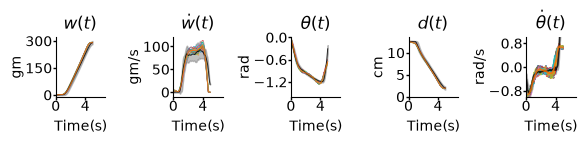

In [39]:
pt = 'COULBA'
exp = 'GobletBeaker'
simulator = ilqg_functions_dict[exp]

#hand tuned params
rotation_cost=2.4
fill_rate_running_cost= 1.584893192461114e-06
fill_cost= 20.
action_cost= 0.01995262314968879

data_norm = normalize_trajectories(data_master_trajectories[pt][exp]['trajectories_control'])
DIST_RIM_TGT, FILL_TIME = data_norm[:,:,3].mean(axis=0)[-1], data_norm.shape[1]

params = Pouring_base.get_params_type()(
                                    action_cost = action_cost,
                                    fill_rate_running_cost = fill_rate_running_cost,
                                    fill_cost=fill_cost,
                                    rotation_cost=rotation_cost,
                                    DIST_TO_RIM_TGT=DIST_RIM_TGT,
                                    )

normed = resample_from_interps(interp_funcs, T=FILL_TIME-1)
uinit_data, _ = get_avg_traj(normed)
uinit_data = uinit_data.reshape((FILL_TIME-1,1))

xs, us = simulator(key, params, ntrial=20,T=FILL_TIME, uinit=uinit_data)
plot_ilqq_trajectories(xs, us, data_norm)


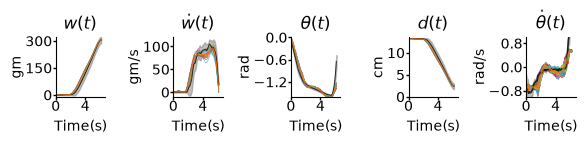

In [40]:
pt = 'FRTHIL'
exp = 'MugVase'
simulator = ilqg_functions_dict[exp]

#hand tuned params
rotation_cost=1.
fill_rate_running_cost= 1.26e-06
fill_cost= 20.
action_cost= 0.02

data_norm = normalize_trajectories(data_master_trajectories[pt][exp]['trajectories_control'])
DIST_RIM_TGT, FILL_TIME = data_norm[:,:,3].mean(axis=0)[-1], data_norm.shape[1]

params = Pouring_base.get_params_type()(
                                    action_cost = action_cost,
                                    fill_rate_running_cost = fill_rate_running_cost,
                                    fill_cost=fill_cost,
                                    rotation_cost=rotation_cost,
                                    DIST_TO_RIM_TGT=DIST_RIM_TGT,
                                    )

normed = resample_from_interps(interp_funcs, T=FILL_TIME-1)
uinit_data, _ = get_avg_traj(normed)
uinit_data = uinit_data.reshape((FILL_TIME-1,1))

xs, us = simulator(key, params, ntrial=20,T=FILL_TIME, uinit=uinit_data)
plot_ilqq_trajectories(xs, us, data_norm)


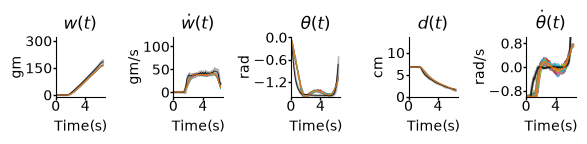

In [41]:
pt = 'INPISI'
exp = 'ConicalBottle'
simulator = ilqg_functions_dict[exp]

#hand tuned params
rotation_cost=1.26
fill_rate_running_cost= 1.26e-05
fill_cost= 31.6
action_cost= 0.0158

data_norm = normalize_trajectories(data_master_trajectories[pt][exp]['trajectories_control'])
DIST_RIM_TGT, FILL_TIME = data_norm[:,:,3].mean(axis=0)[-1], data_norm.shape[1]

params = Pouring_base.get_params_type()(
                                    action_cost = action_cost,
                                    fill_rate_running_cost = fill_rate_running_cost,
                                    fill_cost=fill_cost,
                                    rotation_cost=rotation_cost,
                                    DIST_TO_RIM_TGT=DIST_RIM_TGT,
                                    )

normed = resample_from_interps(interp_funcs, T=FILL_TIME-1)
uinit_data, _ = get_avg_traj(normed)
uinit_data = uinit_data.reshape((FILL_TIME-1,1))

xs, us = simulator(key, params, ntrial=20,T=FILL_TIME, uinit=uinit_data)
plot_ilqq_trajectories(xs, us, data_norm)

In [42]:
#plot inverse optimal control results
df_inverse_model_all = pd.read_csv('data/inverse_model_fitting_results.csv')
df_model_fits = df_inverse_model_all[df_inverse_model_all['model']=='full']

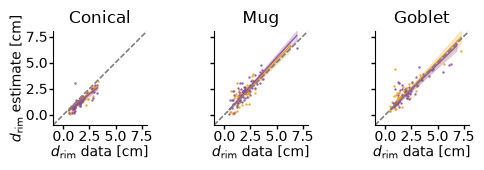

In [43]:
fig, axs = plt.subplots(1, 3, figsize=(7,1.8), sharey=True)
for vid, vessel in enumerate(vessel_list):
    ax = axs[vid]
    for kj, task in enumerate(df_model_fits['task'].unique()):
        x = df_model_fits[(df_model_fits['task']==task) & (df_model_fits['vessel']==vessel) ]['fill_target_data'].values
        y = df_model_fits[(df_model_fits['task']==task) & (df_model_fits['vessel']==vessel) ]['fill_target'].values

        mask = ~np.isnan(y) 
        x_clean = x[mask]
        y_clean = y[mask]

        sort_idx = np.argsort(x_clean)
        x_sorted = x_clean[sort_idx]
        y_sorted = y_clean[sort_idx]
        model, ci = get_regression(x_sorted,y_sorted)
        y_fit = ci["mean"]
        y_ci_lower = ci["mean_ci_lower"]
        y_ci_upper = ci["mean_ci_upper"]
        # Plot regression line
        ax.plot(x_sorted, y_fit, lw=1, color=task_colors_dict[task], alpha=0.9)
        # Plot shaded 95% CI
        ax.fill_between(x_sorted, y_ci_lower, y_ci_upper, color=task_colors_dict[task], alpha=0.2)

        # Plot scatter
        ax.scatter(x_clean, y_clean, alpha=0.9, s=2, linewidths=0.2, label=task, color=colors_dict_all[task])

        ax.set_xlabel(r'$d_\mathrm{rim}$ data [cm]', labelpad=1. )
        if vid==0:
            ax.set_ylabel(r'$d_\mathrm{rim}$ estimate [cm]', labelpad=1.)
        ax.axline((1, 1), slope=1, color = 'gray',  linestyle="--", lw=1, alpha=0.9)
        lims = [-1,8]
        ax.set_xlim(*lims)
        ax.set_ylim(*lims)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.set_aspect('equal')
        ax.set_title(f"{vessel}", )
        ax.tick_params(axis='both', pad=0.8)
        simpleaxis(ax, constrained=False, direction='out', tickLen=3)
plt.show()
plt.close('all')

In [44]:
def plot_boxplot(df, measure, group_col, group_list, colors_dict,
                 ylabel=None, figsize=(3, 2), ncols=None, split_by_task=False,
                 tasks=('self-paced', 'fast'), task_list=None, sharey=True):
    """
    Generic boxplot for model fit parameters.
    
    If split_by_task=True: one subplot per group, boxes split by task.
    If split_by_task=False: single axis, one box per group.
    """
    if split_by_task:
        ncols = ncols or len(group_list)
        fig, axs = plt.subplots(1, ncols, figsize=figsize, sharey=sharey)
        if ncols == 1:
            axs = [axs]
        for vid, grp in enumerate(group_list):
            ax = axs[vid]
            df_sub = df[df[group_col] == grp]
            data = [df_sub[df_sub['task'] == t][measure] for t in tasks]
            draw_boxplot(ax, data, labels=list(tasks),
                          colors=[colors_dict[t] for t in (task_list or tasks)],
                          alpha=0.9)
            ax.set_title(grp)
            ax.tick_params(axis='x', rotation=-18)
            ax.tick_params(axis='both', pad=0.2)
            if vid == 0 and ylabel:
                ax.set_ylabel(ylabel, labelpad=1.)
            simpleaxis(ax, constrained=False, direction='out', tickLen=3)
    else:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        data = [df[df[group_col] == g][measure] for g in group_list]
        draw_boxplot(ax, data, labels=group_list,
                      colors=[colors_dict[g] for g in group_list], alpha=0.75)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='both', pad=0.5)
        if ylabel:
            ax.set_ylabel(ylabel, labelpad=1.)
        simpleaxis(ax, constrained=False, direction='out', tickLen=3)
        plt.tight_layout()

    plt.show()
    plt.close('all')


def draw_boxplot(ax, data, labels, colors, alpha=0.9):
    boxprops = dict(linewidth=0.4, edgecolor='#2C3E50')
    medianprops = dict(color='#2C3E50', linewidth=1.)
    whiskerprops = dict(color='#2C3E50', linewidth=.8, linestyle='-')
    capprops = dict(color='#2C3E50', linewidth=.8)
    flierprops = dict(marker='o', markerfacecolor='#95a5a6', markersize=1.5,
                      linestyle='none', markeredgecolor='#7f8c8d',
                      markeredgewidth=0.2, alpha=0.9)
    ax.set_yscale('log')
    bp = ax.boxplot(data, patch_artist=True, widths=0.55,
                    boxprops=boxprops, medianprops=medianprops,
                    whiskerprops=whiskerprops, capprops=capprops,
                    flierprops=flierprops, showcaps=True, showfliers=True)
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(alpha)
        patch.set_edgecolor('#2C3E50')
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)

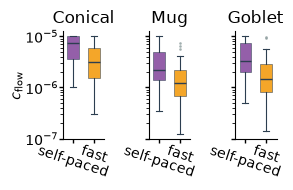

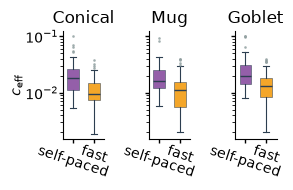

In [45]:

plot_boxplot(df_model_fits, 'fill_rate_running_cost', 'vessel', vessel_list,
             colors_dict_all, ylabel=r'$c_\mathrm{flow}$', figsize=(3, 2),
             split_by_task=True, task_list=task_list)


plot_boxplot(df_model_fits, 'action_cost', 'vessel', vessel_list,
             colors_dict_all, ylabel=r'$c_\mathrm{eff}$', figsize=(3, 2),
             split_by_task=True, task_list=task_list)


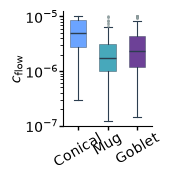

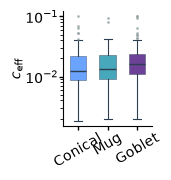

In [46]:

plot_boxplot(df_model_fits, 'fill_rate_running_cost', 'vessel', vessel_list,
             colors_dict_all, ylabel=r'$c_\mathrm{flow}$', figsize=(1.8, 1.9))

plot_boxplot(df_model_fits, 'action_cost', 'vessel', vessel_list,
             colors_dict_all, ylabel=r'$c_\mathrm{eff}$', figsize=(1.8, 1.9))

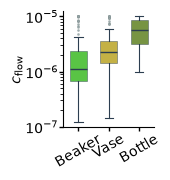

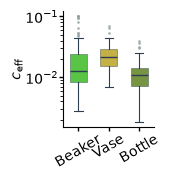

In [47]:

plot_boxplot(df_model_fits, 'fill_rate_running_cost', 'container',
             ['Beaker', 'Vase', 'Bottle'], colors_dict_all,
             ylabel=r'$c_\mathrm{flow}$', figsize=(1.8, 1.9))

plot_boxplot(df_model_fits, 'action_cost', 'container',
             ['Beaker', 'Vase', 'Bottle'], colors_dict_all,
             ylabel=r'$c_\mathrm{eff}$', figsize=(1.8, 1.9))


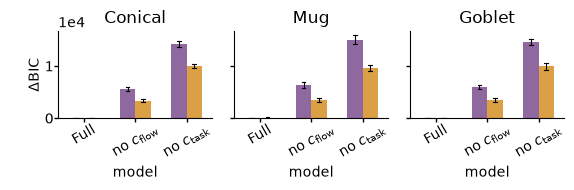

In [48]:
# plot model comparison
df_bic = df_inverse_model_all.copy()
df_bic = df_bic[~(df_bic['model'] == 'no_action')]
df_bic = df_bic.dropna(subset=["test_bic"])

# Compute delta BIC within each comparison group
group_cols = ["pt", "vessel", "container", "task"]
df_bic["delta_bic"] = (
    df_bic["test_bic"]
    - df_bic.groupby(group_cols)["test_bic"].transform("min"))

fig, axs = plt.subplots(1, 3, figsize=(6., 2), sharey=True)

model_labels = {
    'full': 'Full',
    'no_fill_rate': r'no $c_\mathrm{flow}$',
    'no_fill_cost': r'no $c_\mathrm{task}$',
}

# Iterate through each subplot
for i, vessel in enumerate(vessel_list):
    ax = axs[i]
    
    df_sub = df_bic[df_bic['vessel'] == vessel]
        
    # Create barplot
    sns.barplot(data=df_sub, x="model",y="delta_bic",hue="task",palette=task_colors,alpha=0.9,
                dodge=True,width=0.6,errorbar="se",capsize=0.15,err_kws={'linewidth': 0.8, 'color': 'black'},
                hue_order=['self-paced', 'fast'],ax=ax, legend=False
    )
    
    # Format y-axis with scientific notation
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    
    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=30)
    xticks = ax.get_xticks()
    current_labels = [tick.get_text() for tick in ax.get_xticklabels()]
    new_labels = [model_labels.get(label, label) for label in current_labels]
    ax.set_xticks(xticks)
    ax.set_xticklabels(new_labels)
    # Set titles
    ax.set_title(f'{vessel}')
    if i == 0:  # Left column - row titles
        ax.set_ylabel(f'\nΔBIC', labelpad=1.)
    
    if i == len(vessel) - 1: 
        ax.set_xlabel('')
    
    simpleaxis(ax, constrained=True, direction='out', tickLen=3)
    ax.set_title(f'{vessel}', )
    ax.tick_params(axis='both', pad=0.2)

plt.tight_layout()
plt.show()
plt.close('all')
